In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "16"
os.environ["MKL_NUM_THREADS"] = "16"
os.environ["OPENBLAS_NUM_THREADS"] = "16"
os.environ["BLIS_NUM_THREADS"] = "16"
os.environ["VECLIB_MAXIMUM_THREADS"] = "16"
os.environ["NUMEXPR_NUM_THREADS"] = "16"

# 1. Installation, imports et loadings

In [2]:
import os
import glob
import json
from pathlib import Path

!pip install duckdb --quiet
!pip install numpy --quiet
!pip install matplotlib --quiet
!pip install seaborn --quiet
!pip install jinja2 --quiet
!pip install spicy --quiet


import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from scipy.stats import pearsonr

import matplotlib.dates as mdates
!pip install plotly --quiet
!pip install --upgrade nbformat
import plotly.express as px
                                
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

                               
DATA_DIR = Path("/data/gdelt/gdelt_parquet_db")
SOURCE_MAP_PATH = Path("/data/gdelt/gdelt_sources_mapping.json")

parquet_files = sorted(glob.glob(str(DATA_DIR / "gdelt_*.parquet")))
print(f" {len(parquet_files)} fichiers parquet trouvés ({(sum(os.path.getsize(f) for f in parquet_files) / (1024**3)):.2f} Go).")

                                          
con = duckdb.connect()
con.execute("PRAGMA memory_limit='200GB'")

glob_pattern = str(DATA_DIR / "gdelt_*.parquet")
con.execute(f"CREATE OR REPLACE VIEW gkg AS SELECT * FROM read_parquet('{glob_pattern}')")

                                            
with open(SOURCE_MAP_PATH, "r", encoding="utf-8") as f:
    source_map = json.load(f)

src_df = pd.DataFrame({
    "SourceCommonName_ID": [int(k) for k in source_map["id_to_source"].keys()],
    "SourceCommonName": list(source_map["id_to_source"].values()),
})
con.register("src_map", src_df)

print(" Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB")


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip
 137 fichiers parquet trouvés (414.49 Go).
 Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB


In [3]:
con.execute("SET threads TO 16")

# 2. Nettoyage de la base (Création de `gkg_clean`)
Cette étape applique tous nos filtres de qualité d'un seul coup :
1. Suppression des erreurs de formatage sur les dates et d'un unique ID corrompu connu.
2. Réconciliation des `SourceCommonName_ID` manquants (ID = 0) en extrayant le nom de domaine de l'URL (`DocumentIdentifier`) et en le comparant au dictionnaire officiel.
3. Suppression pure et simple des articles qui n'ont ni ID valide, ni correspondance dans le dictionnaire.
## 2.1. Broken ID and no source 

In [4]:
con.execute(r"""
    CREATE OR REPLACE VIEW gkg_clean AS
    
    WITH raw_filtered AS (
        -- 1. Nettoyage initial : dates valides et exclusion des lignes corrompues connues
        SELECT *
        FROM gkg
        WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{14}$')
          AND GKGRECORDID != '20210925181500-T1111'
    )
    
    -- 2. Réparation et filtrage du bruit
    SELECT 
        r.* EXCLUDE (SourceCommonName_ID),
        
        -- On recalcule l'ID : si 0, on prend celui du dico, sinon on garde l'original
        CASE
            WHEN COALESCE(r.SourceCommonName_ID, 0) = 0 THEN m.SourceCommonName_ID
            ELSE r.SourceCommonName_ID
        END AS SourceCommonName_ID
        
    FROM raw_filtered r
    LEFT JOIN src_map m 
      ON RTRIM(regexp_extract(r.DocumentIdentifier, 'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
      
    -- 3. On élimine le bruit (IPs brutes ou sources inconnues du dictionnaire)
    WHERE COALESCE(r.SourceCommonName_ID, 0) != 0 
       OR m.SourceCommonName_ID IS NOT NULL
""")

                    
# bilan_nettoyage = con.execute("""
#     SELECT 
#         '1. GKG Brut' AS Etape, COUNT(*) AS Lignes_Totales 
#     FROM gkg
#     UNION ALL
#     SELECT 
#         '2. GKG Clean', COUNT(*) 
#     FROM gkg_clean
# """).df()

# bilan_nettoyage['Lignes_Supprimees'] = bilan_nettoyage['Lignes_Totales'].iloc[0] - bilan_nettoyage['Lignes_Totales']
# display(bilan_nettoyage.style.format({'Lignes_Totales': '{:,}', 'Lignes_Supprimees': '{:,}'}).hide(axis="index"))

## 2.2 No theme-less

In [5]:
con.execute(r"""
    CREATE OR REPLACE VIEW gkg_themes AS
    
    SELECT *
    FROM gkg_clean
    WHERE EnhancedThemes IS NOT NULL 
      AND EnhancedThemes != ''
""")

# Bilan rapide de la création
# bilan_themes = con.execute("""
#     SELECT 
#         '1. GKG Clean' AS Etape, COUNT(*) AS Lignes 
#     FROM gkg_clean
#     UNION ALL
#     SELECT 
#         '2. GKG Themes (Filtre appliqué)', COUNT(*) 
#     FROM gkg_themes
# """).df()

# bilan_themes['Supprimées'] = bilan_themes['Lignes'].iloc[0] - bilan_themes['Lignes']
# display(bilan_themes.style.format({'Lignes': '{:,}', 'Supprimées': '{:,}'}).hide(axis="index"))
# print("Vue 'gkg_themes' créée avec succès.")

## 2.3 Words outliers

In [6]:
MIN_WORDS = 15     # Exclut les brèves, les flux RSS et les erreurs (ex: 50 mots)
MAX_WORDS = 6500   # Exclut les rapports géants et les pages web entières mal découpées (ex: 4000 mots)

query_words = f"""
    CREATE OR REPLACE VIEW gkg_words AS
    
    SELECT *
    FROM gkg_themes
    WHERE WordCount BETWEEN {MIN_WORDS} AND {MAX_WORDS}
"""
con.execute(query_words)

# bilan_words = con.execute(f"""
#     SELECT 
#         '1. GKG Themes' AS Etape, COUNT(*) AS Lignes 
#     FROM gkg_themes
#     UNION ALL
#     SELECT 
#         '2. GKG Words ({MIN_WORDS} à {MAX_WORDS} mots)', COUNT(*) 
#     FROM gkg_words
# """).df()

# bilan_words['Supprimées'] = bilan_words['Lignes'].iloc[0] - bilan_words['Lignes']
# display(bilan_words.style.format({'Lignes': '{:,}', 'Supprimées': '{:,}'}).hide(axis="index"))

## 2.4 Amount of articles per source

In [7]:
MIN_ARTICLES_PER_SOURCE = 30

query_sources_view = f"""
    CREATE OR REPLACE VIEW gkg_sources AS
    
    WITH ValidSources AS (
        -- 1. On identifie les sources qui atteignent le seuil
        SELECT SourceCommonName_ID
        FROM gkg_words
        WHERE SourceCommonName_ID IS NOT NULL
        GROUP BY SourceCommonName_ID
        HAVING COUNT(*) >= {MIN_ARTICLES_PER_SOURCE}
    )
    -- 2. On filtre la base complète en ne gardant que ces sources
    SELECT w.*
    FROM gkg_words w
    INNER JOIN ValidSources v 
      ON w.SourceCommonName_ID = v.SourceCommonName_ID
"""

con.execute(query_sources_view)

# Bilan du filtrage
# bilan_sources = con.execute(f"""
#     WITH stats_words AS (
#         SELECT COUNT(*) as lignes, COUNT(DISTINCT SourceCommonName_ID) as sources FROM gkg_words
#     ),
#     stats_sources AS (
#         SELECT COUNT(*) as lignes, COUNT(DISTINCT SourceCommonName_ID) as sources FROM gkg_sources
#     )
#     SELECT 
#         '1. GKG Words' AS Etape, 
#         w.lignes AS "Nombre d'articles", 
#         w.sources AS "Sources distinctes"
#     FROM stats_words w
#     UNION ALL
#     SELECT 
#         '2. GKG Sources (>= {MIN_ARTICLES_PER_SOURCE} articles)', 
#         s.lignes, 
#         s.sources
#     FROM stats_sources s
# """).df()

# # Calcul des suppressions
# articles_suppr = bilan_sources["Nombre d'articles"].iloc[0] - bilan_sources["Nombre d'articles"].iloc[1]
# sources_suppr = bilan_sources["Sources distinctes"].iloc[0] - bilan_sources["Sources distinctes"].iloc[1]

# print(f"✅ Vue créée. Bilan du nettoyage :")
# print(f"- Articles supprimés : {articles_suppr:,}")
# print(f"- Sources fantômes/micro-éditeurs éliminés : {sources_suppr:,}")

# display(bilan_sources.style.format({"Nombre d'articles": '{:,}', "Sources distinctes": '{:,}'}).hide(axis="index"))

## 2.5 Years of activity per source

In [8]:
MIN_ACTIVE_YEARS = 2

query_year_view = f"""
    CREATE OR REPLACE VIEW gkg_year AS
    
    WITH ValidSources AS (
        -- On identifie les sources qui ont publié sur au moins X années distinctes
        SELECT SourceCommonName_ID
        FROM gkg_sources
        GROUP BY SourceCommonName_ID
        HAVING COUNT(DISTINCT substr(CAST(DATE AS VARCHAR), 1, 4)) >= {MIN_ACTIVE_YEARS}
    )
    -- On filtre en faisant une jointure interne
    SELECT s.*
    FROM gkg_sources s
    INNER JOIN ValidSources v 
      ON s.SourceCommonName_ID = v.SourceCommonName_ID
"""

con.execute(query_year_view)

# Bilan du filtrage
# bilan_year = con.execute(f"""
#     WITH stats_sources AS (
#         SELECT COUNT(*) as lignes, COUNT(DISTINCT SourceCommonName_ID) as sources FROM gkg_sources
#     ),
#     stats_year AS (
#         SELECT COUNT(*) as lignes, COUNT(DISTINCT SourceCommonName_ID) as sources FROM gkg_year
#     )
#     SELECT 
#         '1. GKG Sources' AS Etape, 
#         s.lignes AS "Nombre d'articles", 
#         s.sources AS "Sources distinctes"
#     FROM stats_sources s
#     UNION ALL
#     SELECT 
#         '2. GKG Year (>= {MIN_ACTIVE_YEARS} ans)', 
#         y.lignes, 
#         y.sources
#     FROM stats_year y
# """).df()

# # Calcul du nettoyage
# articles_suppr = bilan_year["Nombre d'articles"].iloc[0] - bilan_year["Nombre d'articles"].iloc[1]
# sources_suppr = bilan_year["Sources distinctes"].iloc[0] - bilan_year["Sources distinctes"].iloc[1]

# print(f"✅ Vue 'gkg_year' créée. Bilan de l'écrémage éditorial :")
# print(f"- Articles retirés : {articles_suppr:,}")
# print(f"- Sources éphémères éliminées : {sources_suppr:,}")

# display(bilan_year.style.format({"Nombre d'articles": '{:,}', "Sources distinctes": '{:,}'}).hide(axis="index"))

## 2.6 Themes per source

In [9]:
MIN_THEMES = 2

query_final_view = f"""
    CREATE OR REPLACE VIEW gkg_final AS
    
    SELECT *
    FROM gkg_year
    WHERE CASE 
            WHEN EnhancedThemes IS NULL OR EnhancedThemes = '' THEN 0
            ELSE ARRAY_LENGTH(string_split(EnhancedThemes, ';'))
          END >= {MIN_THEMES}
"""

con.execute(query_final_view)

## 2.7 1% of the database
We will only work with 1% of the database.

In [10]:
gkg_final_1pc = con.execute("""
    SELECT *
    FROM gkg_final
    WHERE hash(GKGRECORDID) % 100 = 0
""").df()

# 3. Analysis of the temporal anomalities
## 3.1 Low peak 2020
Our goal is to make sure that the themes frequently mentioned, the theme variety and the tone aren't affected during this low peak.

zoom on the low peak :

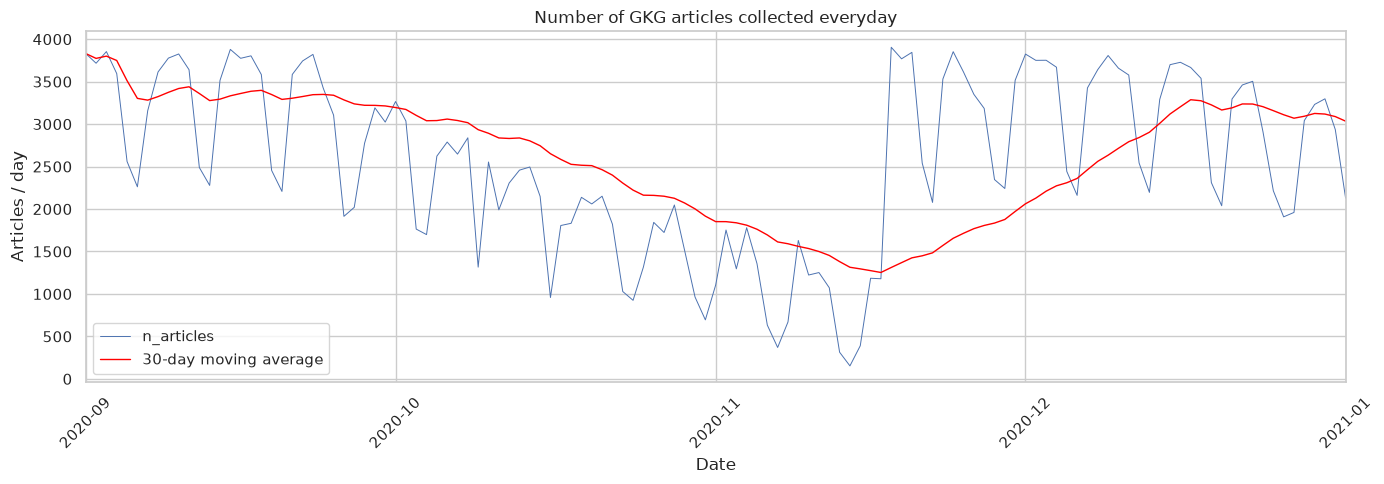

In [11]:
articles_per_day = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_final_1pc
    WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-01'
    AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2021-01-01' 
    GROUP BY day
    ORDER BY day
""").df()

articles_per_day["day"] = pd.to_datetime(articles_per_day["day"])
articles_per_day = articles_per_day.set_index("day")

fig, ax = plt.subplots(figsize=(14, 5))

articles_per_day["n_articles"].plot(ax=ax, linewidth=0.7)
articles_per_day["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax, linewidth=1, color="red", label="30-day moving average"
)

ax.set_title("Number of GKG articles collected everyday")
ax.set_ylabel("Articles / day")
ax.set_xlabel("Date")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

ax.legend()
plt.tight_layout()
plt.show()

finding the extrema to analyze the data there : 

In [12]:
articles_per_day_max_before = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_final_1pc
        WHERE DATE LIKE '202009%'
    GROUP BY day
    ORDER BY n_articles DESC
    LIMIT 1    
""").df()

articles_per_day_min = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_final_1pc
    WHERE DATE LIKE '202011%'
    GROUP BY day
    ORDER BY n_articles ASC
    LIMIT 1    
""").df()

articles_per_day_max_after = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_final_1pc
        WHERE DATE LIKE '202011%'
    GROUP BY day
    ORDER BY n_articles DESC
    LIMIT 1    
""").df()

display(articles_per_day_max_before.style.format({"n_articles": "{:,}"}).hide(axis="index"))
display(articles_per_day_min.style.format({"n_articles": "{:,}"}).hide(axis="index"))
display(articles_per_day_max_after.style.format({"n_articles": "{:,}"}).hide(axis="index"))

day,n_articles
2020-09-15 00:00:00,"3,880"


day,n_articles
2020-11-14 00:00:00,153


day,n_articles
2020-11-18 00:00:00,"3,905"


### 3.1.1 Most frequent themes

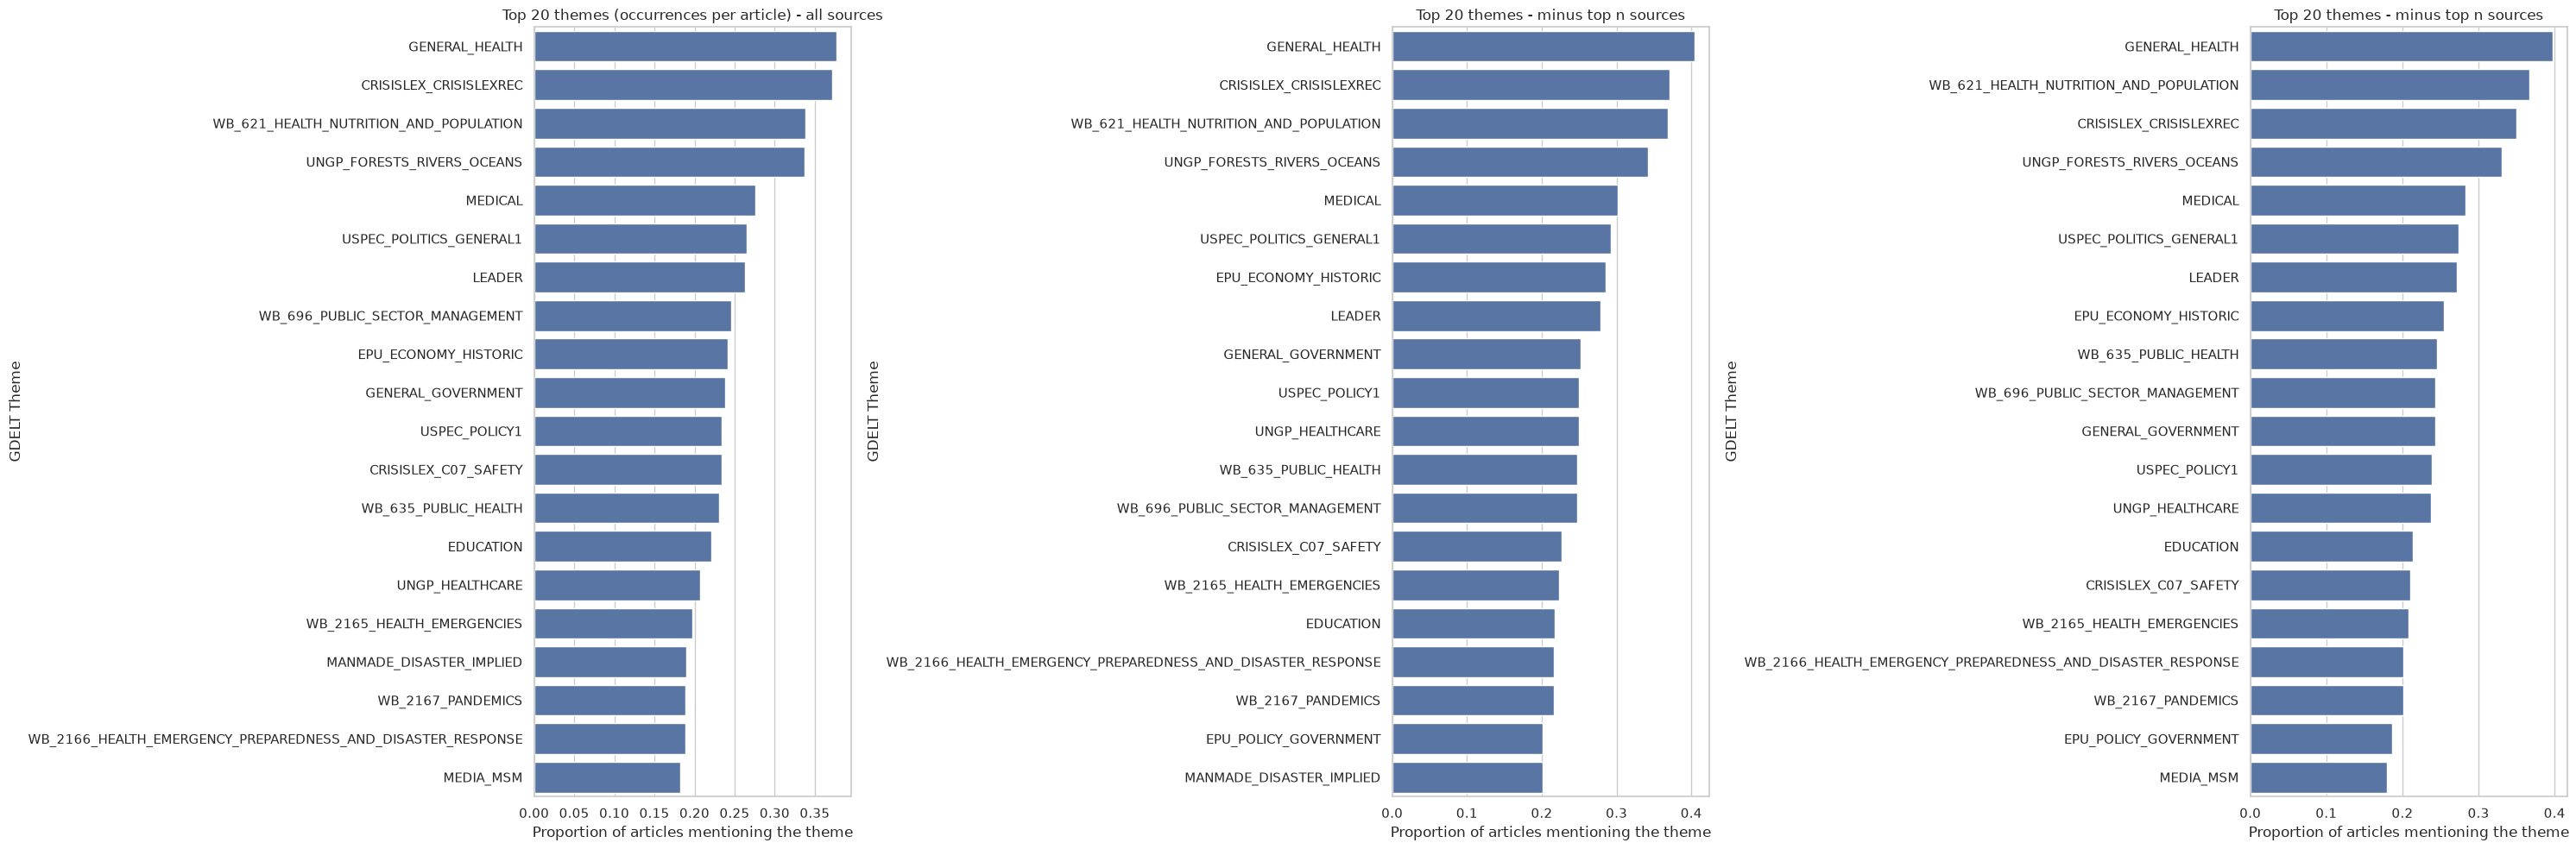

In [13]:
top_themes_2020_09_15 = con.execute("""
    WITH articles AS (
        SELECT COUNT(*) AS n_articles
        FROM gkg_final_1pc
        WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-13'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15'   
    ),

    exploded AS (
        SELECT
            GKGRECORDID,
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-09-13'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-09-15' 
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
    )

    SELECT
        e.theme,
        COUNT(DISTINCT GKGRECORDID) AS articles_contenant_theme,
        COUNT(DISTINCT GKGRECORDID)::DOUBLE / a.n_articles AS proportion
    FROM exploded e
    CROSS JOIN articles a
    GROUP BY e.theme, a.n_articles
    ORDER BY proportion DESC
    LIMIT 20
""").df()

top_themes_2020_11_14 = con.execute("""
    WITH articles AS (
        SELECT COUNT(*) AS n_articles
        FROM gkg_final_1pc
        WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-13'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-15' 
    ),

    exploded AS (
        SELECT
            GKGRECORDID,
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-13'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-15' 
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
    )

    SELECT
        e.theme,
        COUNT(DISTINCT GKGRECORDID) AS articles_contenant_theme,
        COUNT(DISTINCT GKGRECORDID)::DOUBLE / a.n_articles AS proportion
    FROM exploded e
    CROSS JOIN articles a
    GROUP BY e.theme, a.n_articles
    ORDER BY proportion DESC
    LIMIT 20
""").df()

top_themes_2020_11_18 = con.execute("""
    WITH articles AS (
        SELECT COUNT(*) AS n_articles
        FROM gkg_final_1pc
        WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-20' 
    ),

    exploded AS (
        SELECT
            GKGRECORDID,
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2020-11-18'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2020-11-20' 
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
    )

    SELECT
        e.theme,
        COUNT(DISTINCT GKGRECORDID) AS articles_contenant_theme,
        COUNT(DISTINCT GKGRECORDID)::DOUBLE / a.n_articles AS proportion
    FROM exploded e
    CROSS JOIN articles a
    GROUP BY e.theme, a.n_articles
    ORDER BY proportion DESC
    LIMIT 20
""").df()


fig, axes = plt.subplots(1, 3, figsize=(30,10))

sns.barplot(data=top_themes_2020_09_15, x="proportion", y="theme", ax=axes[0])
axes[0].set_title('Top 20 themes (occurrences per article) - all sources')
axes[0].set_xlabel('Proportion of articles mentioning the theme')
axes[0].set_ylabel('GDELT Theme')
 

sns.barplot(data=top_themes_2020_11_14, x="proportion", y="theme", ax=axes[1])
axes[1].set_title('Top 20 themes - minus top n sources')
axes[1].set_xlabel('Proportion of articles mentioning the theme')
axes[1].set_ylabel('GDELT Theme')

sns.barplot(data=top_themes_2020_11_18, x="proportion", y="theme", ax=axes[2])
axes[2].set_title('Top 20 themes - minus top n sources')
axes[2].set_xlabel('Proportion of articles mentioning the theme')
axes[2].set_ylabel('GDELT Theme')

plt.tight_layout()
plt.show()

The most frequent themes are almost the same ones at the 3 extrema (18 shared themes out of 20), and the proportions are also pretty similar.

### 3.1.2 Theme variety per article

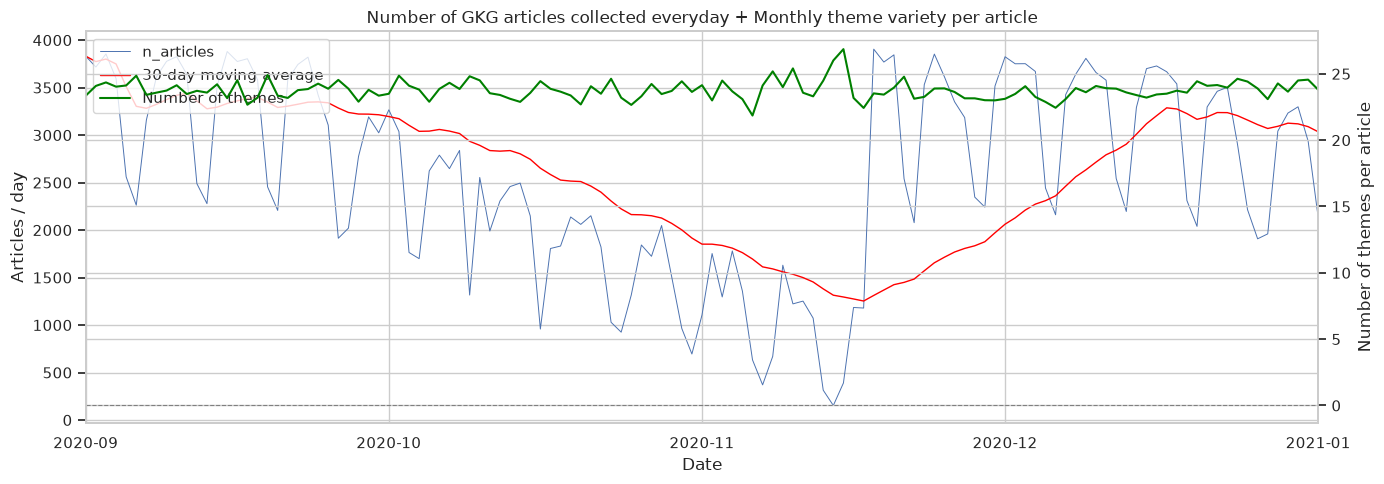

In [14]:
theme_variety_per_article_low_peak_2020 = con.execute("""
    WITH article_themes AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
    FROM (
        SELECT
            DATE,
            GKGRECORDID,
            UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
        FROM gkg_final_1pc
    )
    WHERE theme_raw IS NOT NULL
    AND theme_raw != ''
    GROUP BY day, GKGRECORDID
)

SELECT
    day,
    AVG(nb_themes) AS avg_themes_per_article
FROM article_themes
GROUP BY day
ORDER BY day;
""").df()


fig, ax1 = plt.subplots(figsize=(14, 5))

articles_per_day["n_articles"].plot(ax=ax1, linewidth=0.7)
articles_per_day["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax1, linewidth=1, color="red", label="30-day moving average"
)
ax1.set_ylabel("Articles / day")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(theme_variety_per_article_low_peak_2020["day"], theme_variety_per_article_low_peak_2020["avg_themes_per_article"], color="green", label="Number of themes")
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Number of themes per article")

ax1.set_title("Number of GKG articles collected everyday + Monthly theme variety per article")
ax1.set_xlim(pd.to_datetime('2020-09-01'), pd.to_datetime('2021-01-01'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

The theme variety per article doesn't seem to be affected.

### 3.1.3 Tone

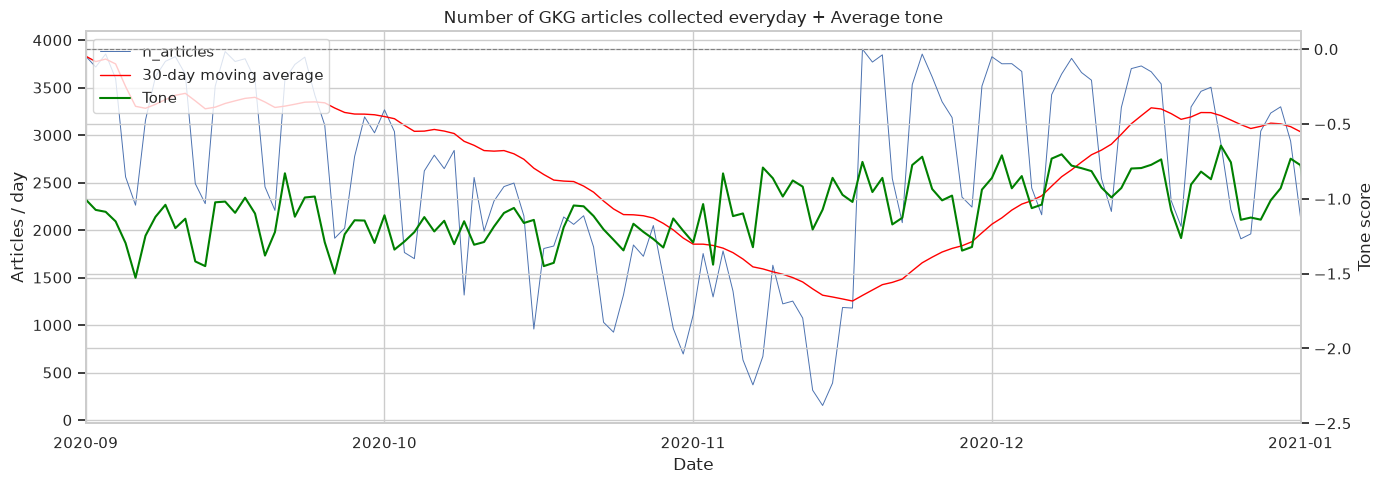

In [15]:
tone_low_peak_2020 = con.execute("""
    SELECT DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
           AVG(Tone) AS avg_tone,
           COUNT(*) AS n
    FROM gkg_final_1pc
    GROUP BY day
    ORDER BY day
""").df()

fig, ax1 = plt.subplots(figsize=(14, 5))

articles_per_day["n_articles"].plot(ax=ax1, linewidth=0.7)
articles_per_day["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax1, linewidth=1, color="red", label="30-day moving average"
)
ax1.set_ylabel("Articles / day")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(tone_low_peak_2020["day"], tone_low_peak_2020["avg_tone"], color="green", label="Tone")
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Tone score")

ax1.set_title("Number of GKG articles collected everyday + Average tone")
ax1.set_xlim(pd.to_datetime('2020-09-01'), pd.to_datetime('2021-01-01'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

The tone doesn't seem to be affected.

### 3.1.4 Impact of the main sources
#### 3.1.4.1 All sources

In [16]:
con.execute("""
    CREATE OR REPLACE TABLE all_sources_2020_09_15 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-09-15'
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
""")

all_sources_2020_09_15 = con.execute("SELECT * FROM all_sources_2020_09_15").df()

In [17]:
con.execute("""
    CREATE OR REPLACE TABLE all_sources_2020_11_14 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
""")

all_sources_2020_11_14 = con.execute("SELECT * FROM all_sources_2020_11_14").df()

In [18]:
con.execute("""
    CREATE OR REPLACE TABLE all_sources_2020_11_18 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-18'
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
""")

all_sources_2020_11_18 = con.execute("SELECT * FROM all_sources_2020_11_18").df()

#### 3.1.4.2 Top n sources

In [19]:
n = 20 # top n sources

con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2020_09_15 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
      WHERE g.SourceCommonName_ID IS NOT NULL
      AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-09-15'
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC
    LIMIT ?
""",[n] )

top_n_sources_2020_09_15 = con.execute("SELECT * FROM top_n_sources_2020_09_15").df()

In [20]:
con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2020_09_15_peak AS
    SELECT
        t.Source_Name, 
        COALESCE(a.Articles, 0) AS Articles
    FROM top_n_sources_2020_09_15 t
    LEFT JOIN all_sources_2020_11_14 a
        ON t.Source_Name = a.Source_Name
    ORDER BY Articles DESC;
""")

top_n_sources_2020_09_15_peak = con.execute("SELECT * FROM top_n_sources_2020_09_15_peak").df()

In [21]:
con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2020_09_15_after AS
    SELECT
        t.Source_Name,
        COALESCE(a.Articles, 0) AS Articles
    FROM top_n_sources_2020_09_15 t
    LEFT JOIN all_sources_2020_11_18 a
        ON t.Source_Name = a.Source_Name
    ORDER BY Articles DESC;
""")

top_n_sources_2020_09_15_after = con.execute("SELECT * FROM top_n_sources_2020_09_15_after").df()

In [22]:
display(HTML(f"""
<div style="display:flex; gap:30px; align-items:flex-start;">
    <div>
        <h4>2020-09-15</h4>
        {top_n_sources_2020_09_15.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>

    <div>
        <h4>2020-09-15 peak</h4>
        {top_n_sources_2020_09_15_peak.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>

    <div>
        <h4>2020-09-15 after</h4>
        {top_n_sources_2020_09_15_after.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>
</div>
""")
)

Source_Name,Source_ID,Articles
iheart.com,82787,"7,319"
msn.com,427,"5,284"
zazoom.it,36148,"4,492"
yahoo.com,81,"2,540"
sina.com.cn,34473,"2,527"
reuters.com,175,"2,483"
tribunnews.com,26651,"2,154"
haberler.com,6652,"1,750"
prnewswire.com,8623,"1,603"
tin247.com,153611,"1,468"


In [23]:
con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2020_11_14 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
      WHERE g.SourceCommonName_ID IS NOT NULL
      AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-14'
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC
    LIMIT ?
""",[n] )

top_n_sources_2020_11_14 = con.execute("SELECT * FROM top_n_sources_2020_11_14").df()

In [24]:
con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2020_11_14_before AS
    SELECT
        t.Source_Name,
        COALESCE(a.Articles, 0) AS Articles
    FROM top_n_sources_2020_11_14 t
    LEFT JOIN all_sources_2020_09_15 a
        ON t.Source_Name = a.Source_Name
    ORDER BY Articles DESC;
""")

top_n_sources_2020_11_14_before = con.execute("SELECT * FROM top_n_sources_2020_11_14_before").df()

In [25]:
con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2020_11_14_after AS
    SELECT
        t.Source_Name,
        COALESCE(a.Articles, 0) AS Articles
    FROM top_n_sources_2020_11_14 t
    LEFT JOIN all_sources_2020_11_18 a
        ON t.Source_Name = a.Source_Name
    ORDER BY Articles DESC;
""")

top_n_sources_2020_11_14_after = con.execute("SELECT * FROM top_n_sources_2020_11_14_after").df()

In [26]:
display(HTML(f"""
<div style="display:flex; gap:30px; align-items:flex-start;">
    <div>
        <h4>2020-11-14 before</h4>
        {top_n_sources_2020_11_14_before.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>

    <div>
        <h4>2020-11-14</h4>
        {top_n_sources_2020_11_14.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>

    <div>
        <h4>2020-11-14 after</h4>
        {top_n_sources_2020_11_14_after.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>
</div>
""")
)

Source_Name,Articles
iheart.com,"7,319"
msn.com,"5,284"
zazoom.it,"4,492"
yahoo.com,"2,540"
sina.com.cn,"2,527"
reuters.com,"2,483"
tribunnews.com,"2,154"
haberler.com,"1,750"
tin247.com,"1,468"
sina.com.tw,"1,261"


In [27]:
con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2020_11_18 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
      WHERE g.SourceCommonName_ID IS NOT NULL
      AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2020-11-18'
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC
    LIMIT ?
""",[n] )

top_n_sources_2020_11_18 = con.execute("SELECT * FROM top_n_sources_2020_11_18").df()

In [28]:
con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2020_11_18_before AS
    SELECT
        t.Source_Name,
        COALESCE(a.Articles, 0) AS Articles
    FROM top_n_sources_2020_11_18 t
    LEFT JOIN all_sources_2020_09_15 a
        ON t.Source_Name = a.Source_Name
    ORDER BY Articles DESC;
""")

top_n_sources_2020_11_18_before = con.execute("SELECT * FROM top_n_sources_2020_11_18_before").df()

In [29]:
con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2020_11_18_peak AS
    SELECT
        t.Source_Name,
        COALESCE(a.Articles, 0) AS Articles
    FROM top_n_sources_2020_11_18 t
    LEFT JOIN all_sources_2020_11_14 a
        ON t.Source_Name = a.Source_Name
    ORDER BY Articles DESC;
""")

top_n_sources_2020_11_18_peak = con.execute("SELECT * FROM top_n_sources_2020_11_18_peak").df()

In [30]:
display(HTML(f"""
<div style="display:flex; gap:30px; align-items:flex-start;">
    <div>
        <h4>2020-11-18 before</h4>
        {top_n_sources_2020_11_18_before.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>

    <div>
        <h4>2020-11-18 peak</h4>
        {top_n_sources_2020_11_18_peak.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>

    <div>
        <h4>2020-11-18</h4>
        {top_n_sources_2020_11_18.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>
</div>
""")
)

Source_Name,Articles
iheart.com,"7,319"
msn.com,"5,284"
zazoom.it,"4,492"
yahoo.com,"2,540"
sina.com.cn,"2,527"
reuters.com,"2,483"
tribunnews.com,"2,154"
haberler.com,"1,750"
prnewswire.com,"1,603"
tin247.com,"1,468"


#### 3.1.4.3 Percentage variation between the extrema - number of articles collected

In [91]:
nb_sources_all_sources = [
    all_sources_2020_09_15["Articles"].sum(),
    all_sources_2020_11_14["Articles"].sum(),
    all_sources_2020_11_18["Articles"].sum()    
]

nb_sources_top_n_sources_2020_09_15 = [
    top_n_sources_2020_09_15["Articles"].sum(),
    top_n_sources_2020_09_15_peak["Articles"].sum(),
    top_n_sources_2020_09_15_after["Articles"].sum()
]

nb_sources_top_n_sources_2020_11_14 = [
    top_n_sources_2020_11_14_before["Articles"].sum(),
    top_n_sources_2020_11_14["Articles"].sum(),
    top_n_sources_2020_11_14_after["Articles"].sum()    
]

nb_sources_top_n_sources_2020_11_18 = [
    top_n_sources_2020_11_18_before["Articles"].sum(),
    top_n_sources_2020_11_18_peak["Articles"].sum(),
    top_n_sources_2020_11_18["Articles"].sum()    
]

nb_sources_minus_top_n_sources_2020_09_15 = [ 
    nb_sources_all_sources[0] - nb_sources_top_n_sources_2020_09_15[0],
    nb_sources_all_sources[1] - nb_sources_top_n_sources_2020_09_15[1],
    nb_sources_all_sources[2] - nb_sources_top_n_sources_2020_09_15[2]
]

nb_sources_minus_top_n_sources_2020_11_14= [ 
    nb_sources_all_sources[0] - nb_sources_top_n_sources_2020_11_14[0],
    nb_sources_all_sources[1] - nb_sources_top_n_sources_2020_11_14[1],
    nb_sources_all_sources[2] - nb_sources_top_n_sources_2020_11_14[2]
]

nb_sources_minus_top_n_sources_2020_11_18= [ 
    nb_sources_all_sources[0] - nb_sources_top_n_sources_2020_11_18[0],
    nb_sources_all_sources[1] - nb_sources_top_n_sources_2020_11_18[1],
    nb_sources_all_sources[2] - nb_sources_top_n_sources_2020_11_18[2]
]

In [32]:
res1_values_all_sources = round(100 * (nb_sources_all_sources[1] / nb_sources_all_sources[0] - 1), 2)
res2_values_all_sources = round(100 * (nb_sources_all_sources[2] / nb_sources_all_sources[1] - 1), 2)

res1_values_top_n_sources_2020_09_15 = round(100 * (nb_sources_top_n_sources_2020_09_15[1] / nb_sources_top_n_sources_2020_09_15[0] - 1), 2)
res2_values_top_n_sources_2020_09_15 = round(100 * (nb_sources_top_n_sources_2020_09_15[2] / nb_sources_top_n_sources_2020_09_15[1] - 1), 2)

res1_values_minus_top_n_sources_2020_09_15 = round(100 * (nb_sources_minus_top_n_sources_2020_09_15[1] / nb_sources_minus_top_n_sources_2020_09_15[0] - 1), 2)
res2_values_minus_top_n_sources_2020_09_15 = round(100 * (nb_sources_minus_top_n_sources_2020_09_15[2] / nb_sources_minus_top_n_sources_2020_09_15[1] - 1), 2)

res1_values_top_n_sources_2020_11_14 = round(100 * (nb_sources_top_n_sources_2020_11_14[1] / nb_sources_top_n_sources_2020_11_14[0] - 1), 2)
res2_values_top_n_sources_2020_11_14 = round(100 * (nb_sources_top_n_sources_2020_11_14[2] / nb_sources_top_n_sources_2020_11_14[1] - 1), 2)

res1_values_minus_top_n_sources_2020_11_14 = round(100 * (nb_sources_minus_top_n_sources_2020_11_14[1] / nb_sources_minus_top_n_sources_2020_11_14[0] - 1), 2)
res2_values_minus_top_n_sources_2020_11_14 = round(100 * (nb_sources_minus_top_n_sources_2020_11_14[2] / nb_sources_minus_top_n_sources_2020_11_14[1] - 1), 2)

res1_values_top_n_sources_2020_11_18 = round(100 * (nb_sources_top_n_sources_2020_11_18[1] / nb_sources_top_n_sources_2020_11_18[0] - 1), 2)
res2_values_top_n_sources_2020_11_18 = round(100 * (nb_sources_top_n_sources_2020_11_18[2] / nb_sources_top_n_sources_2020_11_18[1] - 1), 2)

res1_values_minus_top_n_sources_2020_11_18 = round(100 * (nb_sources_minus_top_n_sources_2020_11_18[1] / nb_sources_minus_top_n_sources_2020_11_18[0] - 1), 2)
res2_values_minus_top_n_sources_2020_11_18 = round(100 * (nb_sources_minus_top_n_sources_2020_11_18[2] / nb_sources_minus_top_n_sources_2020_11_18[1] - 1), 2)

In [33]:
print ("percentage variation all sources - down :", res1_values_all_sources, "%")
print ("percentage variation all sources - up :", res2_values_all_sources, "%\n")

print ("percentage variation top n sources 2020-09-15 - down :", res1_values_top_n_sources_2020_09_15, "%")
print ("percentage variation top n sources 2020-09-15 - up :", res2_values_top_n_sources_2020_09_15, "%\n")

print ("percentage variation minus top n sources 2020-09-15 - down :", res1_values_minus_top_n_sources_2020_09_15, "%")
print ("percentage variation minus top n sources 2020-09-15 - up :", res2_values_minus_top_n_sources_2020_09_15, "%\n")

print ("percentage variation top n sources 2020-11-14 - down :", res1_values_top_n_sources_2020_11_14, "%")
print ("percentage variation top n sources 2020-11-14 - up :", res2_values_top_n_sources_2020_11_14, "%\n")

print ("percentage variation minus top n sources 2020-11-14 - down :", res1_values_minus_top_n_sources_2020_11_14, "%")
print ("percentage variation minus top n sources 2020-11-14 - up :", res2_values_minus_top_n_sources_2020_11_14, "%\n")

print ("percentage variation top n sources 2020-11-18 - down :", res1_values_top_n_sources_2020_11_18, "%")
print ("percentage variation top n sources 2020-11-18 - up :", res2_values_top_n_sources_2020_11_18, "%\n")

print ("percentage variation minus top n sources 2020-11-18 - down :", res1_values_minus_top_n_sources_2020_11_18, "%")
print ("percentage variation minus top n sources 2020-11-18 - up :", res2_values_minus_top_n_sources_2020_11_18, "%\n")

percentage variation all sources - down : -96.01 %
percentage variation all sources - up : 2333.73 %

percentage variation top n sources 2020-09-15 - down : -96.86 %
percentage variation top n sources 2020-09-15 - up : 2560.15 %

percentage variation minus top n sources 2020-09-15 - down : -95.9 %
percentage variation minus top n sources 2020-09-15 - up : 2312.22 %

percentage variation top n sources 2020-11-14 - down : -94.33 %
percentage variation top n sources 2020-11-14 - up : 1452.81 %

percentage variation minus top n sources 2020-11-14 - down : -96.18 %
percentage variation minus top n sources 2020-11-14 - up : 2473.89 %

percentage variation top n sources 2020-11-18 - down : -96.52 %
percentage variation top n sources 2020-11-18 - up : 2541.84 %

percentage variation minus top n sources 2020-11-18 - down : -95.94 %
percentage variation minus top n sources 2020-11-18 - up : 2312.5 %



The variation is very stable, which is reassuring.

#### 3.1.4.4 Percentage of articles published by the top sources at each extrema
##### 3.1.4.4.1 Top n sources 2020-09-15
We want to see what percentage the top sources of 2020-09-15 (pre-peak top sources) accounts for on each extrema.

In [93]:
top_n_sources_2020_11_14_max = con.execute("""
    SELECT i.Source_Name, t.Articles
    FROM (
        SELECT Source_Name
        FROM top_n_sources_2020_09_15
        INTERSECT
        SELECT Source_Name
        FROM top_n_sources_2020_11_14
    ) AS i
    JOIN top_n_sources_2020_11_14 AS t
        ON i.Source_Name = t.Source_Name
    ORDER BY t.Articles DESC
""").df()

display(top_n_sources_2020_11_14_max.style.format({"Articles": "{:,}"}).hide(axis="index"))

Source_Name,Articles
tribunnews.com,191
tin247.com,191
msn.com,186
iheart.com,127
zazoom.it,108
reuters.com,104
indiatimes.com,77
yahoo.com,74
haberler.com,61
sina.com.tw,53


In [94]:
top_n_sources_2020_11_18_max = con.execute("""
    SELECT i.Source_Name, t.Articles
    FROM (
        SELECT Source_Name
        FROM top_n_sources_2020_09_15
        INTERSECT
        SELECT Source_Name
        FROM top_n_sources_2020_11_18
    ) AS i
    JOIN top_n_sources_2020_11_18 AS t
        ON i.Source_Name = t.Source_Name
    ORDER BY t.Articles DESC
""").df()

display(top_n_sources_2020_11_18_max.style.format({"Articles": "{:,}"}).hide(axis="index"))

Source_Name,Articles
iheart.com,"6,494"
zazoom.it,"4,494"
msn.com,"3,991"
reuters.com,"2,963"
sina.com.cn,"1,916"
tribunnews.com,"1,844"
yahoo.com,"1,531"
prnewswire.com,"1,524"
haberler.com,"1,351"
finanznachrichten.de,"1,290"


In [95]:
res_pc_articles_by_top_n_sources_2020_09_15 = round(100 * (top_n_sources_2020_09_15["Articles"].sum() / nb_sources_all_sources[0]), 2)
res_pc_articles_by_top_n_sources_2020_11_14 = round(100 * (top_n_sources_2020_11_14_max["Articles"].sum() / nb_sources_all_sources[1]), 2)
res_pc_articles_by_top_n_sources_2020_11_18 = round(100 * (top_n_sources_2020_11_18_max["Articles"].sum() / nb_sources_all_sources[2]), 2)

print ("percentage articles published by the top n sources 2020-09-15 :", res_pc_articles_by_top_n_sources_2020_09_15, "%\n")
print ("percentage articles published by the top n sources 2020-11-14 :", res_pc_articles_by_top_n_sources_2020_11_14, "%\n")
print ("percentage articles published by the top n sources 2020-11-18 :", res_pc_articles_by_top_n_sources_2020_11_18, "%\n")

percentage articles published by the top n sources 2020-09-15 : 0.29 %

percentage articles published by the top n sources 2020-11-14 : 8.07 %

percentage articles published by the top n sources 2020-11-18 : 9.29 %



##### 3.1.4.4.2 Top n sources 2020-11-14
We want to see what percentage the top sources of 2020-11-14 (peak top sources) accounts for on each extrema.

In [96]:
top_n_sources_2020_09_15_min = con.execute("""
    SELECT i.Source_Name, t.Articles
    FROM (
        SELECT Source_Name
        FROM top_n_sources_2020_09_15
        INTERSECT
        SELECT Source_Name
        FROM top_n_sources_2020_11_14
    ) AS i
    JOIN top_n_sources_2020_09_15 AS t
        ON i.Source_Name = t.Source_Name
    ORDER BY t.Articles DESC
""").df()

display(top_n_sources_2020_09_15_min.style.format({"Articles": "{:,}"}).hide(axis="index"))

Source_Name,Articles
iheart.com,"7,319"
msn.com,"5,284"
zazoom.it,"4,492"
yahoo.com,"2,540"
sina.com.cn,"2,527"
reuters.com,"2,483"
tribunnews.com,"2,154"
haberler.com,"1,750"
tin247.com,"1,468"
sina.com.tw,"1,261"


In [97]:
top_n_sources_2020_11_18_min = con.execute("""
    SELECT i.Source_Name, t.Articles
    FROM (
        SELECT Source_Name
        FROM top_n_sources_2020_11_14
        INTERSECT
        SELECT Source_Name
        FROM top_n_sources_2020_11_18
    ) AS i
    JOIN top_n_sources_2020_11_18 AS t
        ON i.Source_Name = t.Source_Name
    ORDER BY t.Articles DESC
""").df()

display(top_n_sources_2020_11_18_min.style.format({"Articles": "{:,}"}).hide(axis="index"))

Source_Name,Articles
iheart.com,"6,494"
zazoom.it,"4,494"
msn.com,"3,991"
reuters.com,"2,963"
sina.com.cn,"1,916"
tribunnews.com,"1,844"
yahoo.com,"1,531"
haberler.com,"1,351"
tin247.com,"1,166"
indiatimes.com,"1,009"


In [99]:
res_pc_articles_by_top_n_sources_2020_09_15 = round(100 * (top_n_sources_2020_09_15_min["Articles"].sum() / nb_sources_all_sources[0]), 2)
res_pc_articles_by_top_n_sources_2020_11_14 = round(100 * (top_n_sources_2020_11_14["Articles"].sum() / nb_sources_all_sources[1]), 2)
res_pc_articles_by_top_n_sources_2020_11_18 = round(100 * (top_n_sources_2020_11_18_min["Articles"].sum() / nb_sources_all_sources[2]), 2)

print ("percentage articles published by the top n sources 2020-09-15 :", res_pc_articles_by_top_n_sources_2020_09_15, "%\n")
print ("percentage articles published by the top n sources 2020-11-14 :", res_pc_articles_by_top_n_sources_2020_11_14, "%\n")
print ("percentage articles published by the top n sources 2020-11-18 :", res_pc_articles_by_top_n_sources_2020_11_18, "%\n")

percentage articles published by the top n sources 2020-09-15 : 8.51 %

percentage articles published by the top n sources 2020-11-14 : 0.78 %

percentage articles published by the top n sources 2020-11-18 : 7.74 %



##### 3.1.4.4.3 Top n sources 2020-11-18
We want to see what percentage the top sources of 2020-11-18 (post-peak top sources) accounts for on each extrema.

In [100]:
top_n_sources_2020_09_15_max = con.execute("""
    SELECT i.Source_Name, t.Articles
    FROM (
        SELECT Source_Name
        FROM top_n_sources_2020_11_18
        INTERSECT
        SELECT Source_Name
        FROM top_n_sources_2020_09_15
    ) AS i
    JOIN top_n_sources_2020_09_15 AS t
        ON i.Source_Name = t.Source_Name
    ORDER BY t.Articles DESC
""").df()

display(top_n_sources_2020_09_15_max.style.format({"Articles": "{:,}"}).hide(axis="index"))

Source_Name,Articles
iheart.com,"7,319"
msn.com,"5,284"
zazoom.it,"4,492"
yahoo.com,"2,540"
sina.com.cn,"2,527"
reuters.com,"2,483"
tribunnews.com,"2,154"
haberler.com,"1,750"
prnewswire.com,"1,603"
tin247.com,"1,468"


In [101]:
top_n_sources_2020_11_14_max = con.execute("""
    SELECT i.Source_Name, t.Articles
    FROM (
        SELECT Source_Name
        FROM top_n_sources_2020_11_18
        INTERSECT
        SELECT Source_Name
        FROM top_n_sources_2020_11_14
    ) AS i
    JOIN top_n_sources_2020_11_14 AS t
        ON i.Source_Name = t.Source_Name
    ORDER BY t.Articles DESC
""").df()

display(top_n_sources_2020_11_14_max.style.format({"Articles": "{:,}"}).hide(axis="index"))

Source_Name,Articles
tribunnews.com,191
tin247.com,191
msn.com,186
iheart.com,127
zazoom.it,108
reuters.com,104
baomoi.com,82
indiatimes.com,77
yahoo.com,74
haberler.com,61


In [102]:
res_pc_articles_by_top_n_sources_2020_09_15 = round(100 * (top_n_sources_2020_09_15_max["Articles"].sum() / nb_sources_all_sources[0]), 2)
res_pc_articles_by_top_n_sources_2020_11_14 = round(100 * (top_n_sources_2020_11_14_max["Articles"].sum() / nb_sources_all_sources[1]), 2)
res_pc_articles_by_top_n_sources_2020_11_18 = round(100 * (top_n_sources_2020_11_18["Articles"].sum() / nb_sources_all_sources[2]), 2)

print ("percentage articles published by the top n sources 2020-09-15 :", res_pc_articles_by_top_n_sources_2020_09_15, "%\n")
print ("percentage articles published by the top n sources 2020-11-14 :", res_pc_articles_by_top_n_sources_2020_11_14, "%\n")
print ("percentage articles published by the top n sources 2020-11-18 :", res_pc_articles_by_top_n_sources_2020_11_18, "%\n")

percentage articles published by the top n sources 2020-09-15 : 10.24 %

percentage articles published by the top n sources 2020-11-14 : 8.61 %

percentage articles published by the top n sources 2020-11-18 : 0.31 %



Since the proportion of articles published by top contributors remains stable at all three points on the curve, their impact remains consistent even when there is a sharp fluctuation in the volume of published articles. Therefore, the top contributors don't bias the results!

## 3.2 Increase 2023
Our goal is to make sure that the themes frequently mentioned, the theme variety and the tone aren't affected during this increase.

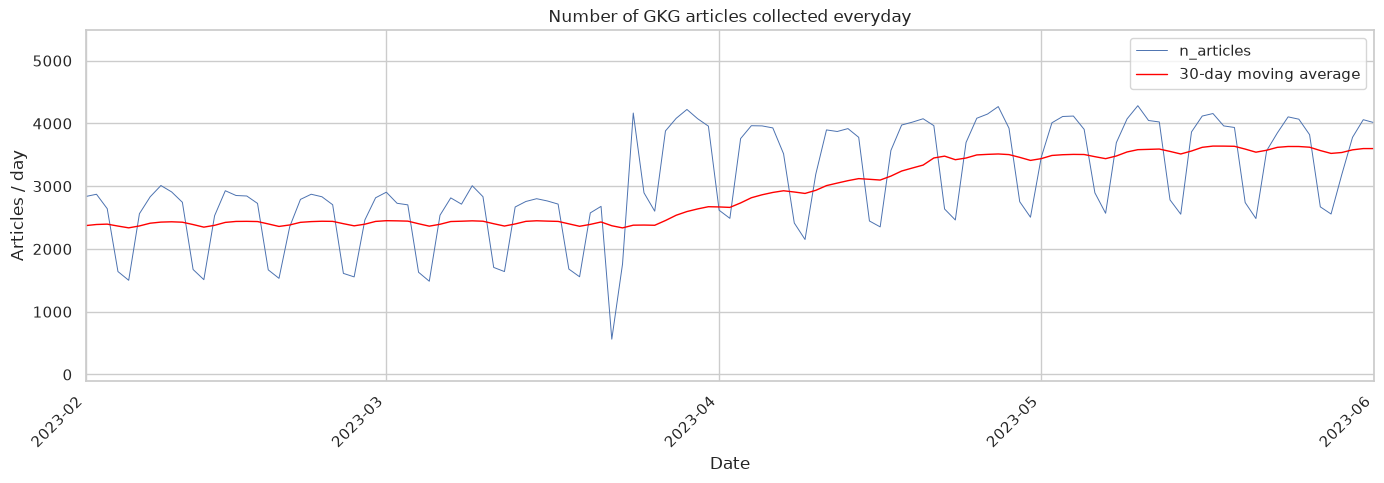

In [54]:
articles_per_day = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_final_1pc
    GROUP BY day
    ORDER BY day
""").df()

articles_per_day["day"] = pd.to_datetime(articles_per_day["day"])
articles_per_day = articles_per_day.set_index("day")

fig, ax = plt.subplots(figsize=(14, 5))

articles_per_day["n_articles"].plot(ax=ax, linewidth=0.7)
articles_per_day["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax, linewidth=1, color="red", label="30-day moving average"
)

ax.set_title("Number of GKG articles collected everyday")
ax.set_ylabel("Articles / day")
ax.set_xlabel("Date")

ax.set_xlim(pd.to_datetime('2023-02-01'), pd.to_datetime('2023-06-01'))

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

ax.legend()
plt.tight_layout()
plt.show()

finding the extrema to analyze the data there : 

In [55]:
articles_per_day_min = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_final_1pc
        WHERE DATE LIKE '202303%'
    GROUP BY day
    ORDER BY n_articles ASC
    LIMIT 1    
""").df()

articles_per_day_max = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_final_1pc
        WHERE DATE LIKE '202303%'
    GROUP BY day
    ORDER BY n_articles DESC
    LIMIT 1    
""").df()

display(articles_per_day_min.style.format({"n_articles": "{:,}"}).hide(axis="index"))
display(articles_per_day_max.style.format({"n_articles": "{:,}"}).hide(axis="index"))

day,n_articles
2023-03-22 00:00:00,563


day,n_articles
2023-03-29 00:00:00,"4,223"


### 3.2.1 Most frequent themes

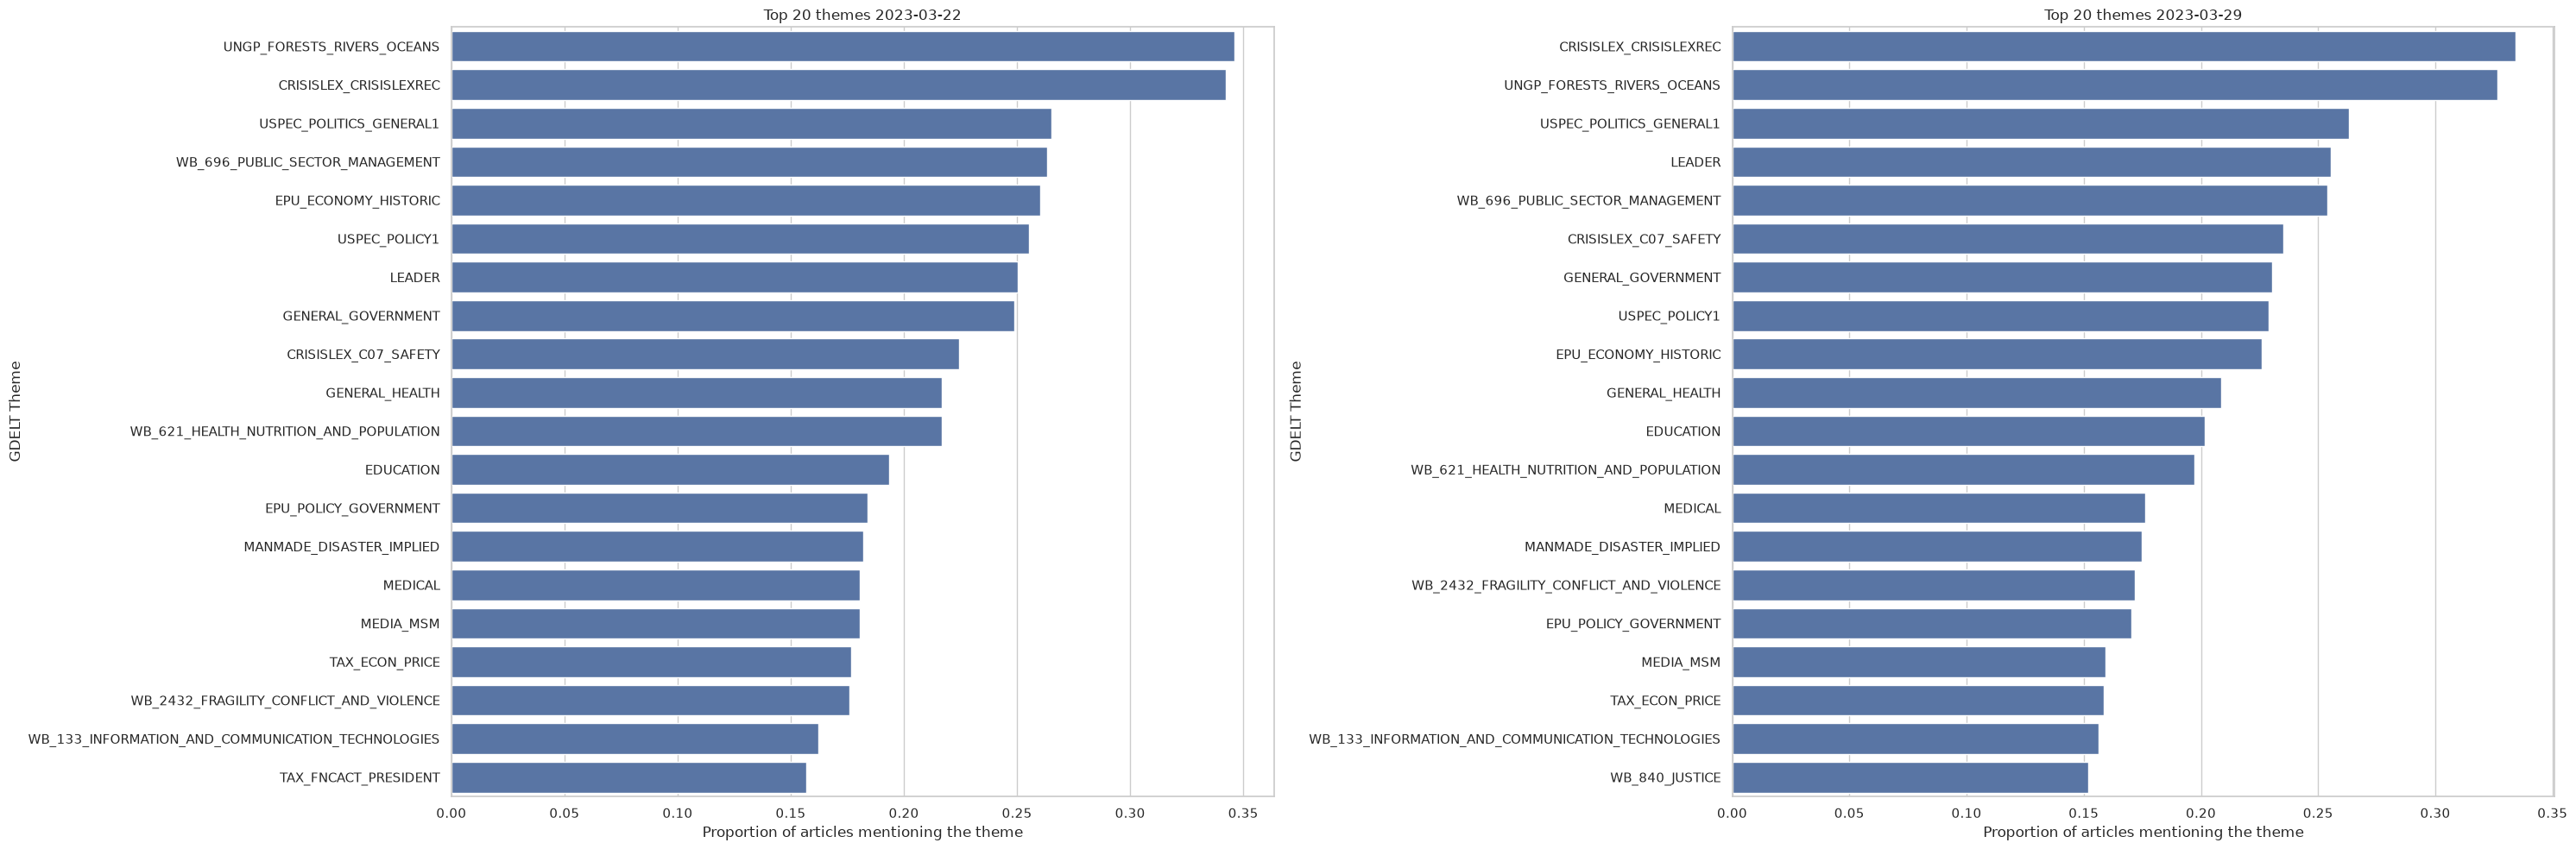

In [56]:
top_themes_2023_03_22 = con.execute("""
    WITH articles AS (
        SELECT COUNT(*) AS n_articles
        FROM gkg_final_1pc
        WHERE  STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-20'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'                                 
    ),

    exploded AS (
        SELECT
            GKGRECORDID,
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-20'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'   
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
    )

    SELECT
        e.theme,
        COUNT(DISTINCT GKGRECORDID) AS articles_contenant_theme,
        COUNT(DISTINCT GKGRECORDID)::DOUBLE / a.n_articles AS proportion
    FROM exploded e
    CROSS JOIN articles a
    GROUP BY e.theme, a.n_articles
    ORDER BY proportion DESC
    LIMIT 20
""").df()

top_themes_2023_03_29 = con.execute("""
    WITH articles AS (
        SELECT COUNT(*) AS n_articles
        FROM gkg_final_1pc
        WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-31'   
    ),

    exploded AS (
        SELECT
            GKGRECORDID,
            split_part(TRIM(theme_raw), ',', 1) AS theme
        FROM (
            SELECT
                GKGRECORDID,
                UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
            FROM gkg_final_1pc
            WHERE STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
            AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-31'   
        )
        WHERE theme_raw IS NOT NULL
        AND theme_raw != ''
    )

    SELECT
        e.theme,
        COUNT(DISTINCT GKGRECORDID) AS articles_contenant_theme,
        COUNT(DISTINCT GKGRECORDID)::DOUBLE / a.n_articles AS proportion
    FROM exploded e
    CROSS JOIN articles a
    GROUP BY e.theme, a.n_articles
    ORDER BY proportion DESC
    LIMIT 20
""").df()


fig, axes = plt.subplots(1, 2, figsize=(30,10))

sns.barplot(data=top_themes_2023_03_22, x="proportion", y="theme", ax=axes[0])
axes[0].set_title('Top 20 themes 2023-03-22')
axes[0].set_xlabel('Proportion of articles mentioning the theme')
axes[0].set_ylabel('GDELT Theme')

sns.barplot(data=top_themes_2023_03_29, x="proportion", y="theme", ax=axes[1])
axes[1].set_title('Top 20 themes 2023-03-29')
axes[1].set_xlabel('Proportion of articles mentioning the theme')
axes[1].set_ylabel('GDELT Theme')

plt.tight_layout()
plt.show()

The most frequent themes are almost the same ones at the 3 extrema (19 shared themes out of 20), and the proportions are also pretty similar.

### 3.2.2 Theme variety per article

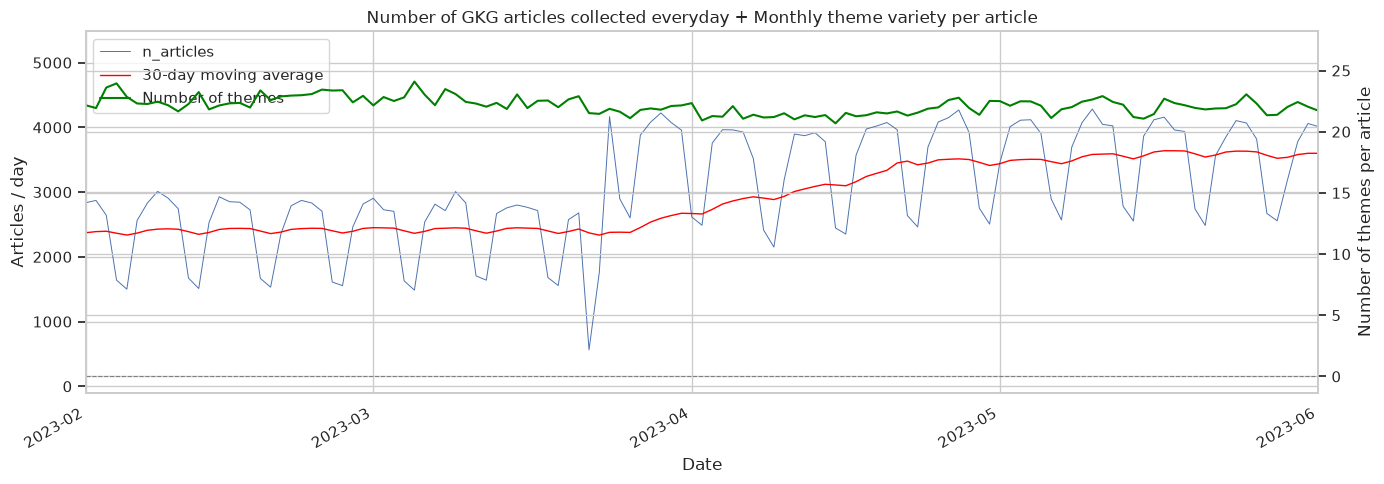

In [57]:
theme_variety_per_article_increase_2023 = con.execute("""
    WITH article_themes AS (
    SELECT
        DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
        COUNT(DISTINCT split_part(TRIM(theme_raw), ',', 1)) AS nb_themes
    FROM (
        SELECT
            DATE,
            GKGRECORDID,
            UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
        FROM gkg_final_1pc
    )
    WHERE theme_raw IS NOT NULL
    AND theme_raw != ''
    GROUP BY day, GKGRECORDID
)

SELECT
    day,
    AVG(nb_themes) AS avg_themes_per_article
FROM article_themes
GROUP BY day
ORDER BY day;
""").df()


fig, ax1 = plt.subplots(figsize=(14, 5))

articles_per_day["n_articles"].plot(ax=ax1, linewidth=0.7)
articles_per_day["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax1, linewidth=1, color="red", label="30-day moving average"
)
ax1.set_ylabel("Articles / day")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(theme_variety_per_article_increase_2023["day"], theme_variety_per_article_increase_2023["avg_themes_per_article"], color="green", label="Number of themes")
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Number of themes per article")

ax1.set_title("Number of GKG articles collected everyday + Monthly theme variety per article")
ax1.set_xlim(pd.to_datetime('2023-02-01'), pd.to_datetime('2023-06-01'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

The theme variety per article doesn't seem to be affected.

### 3.2.3 Tone

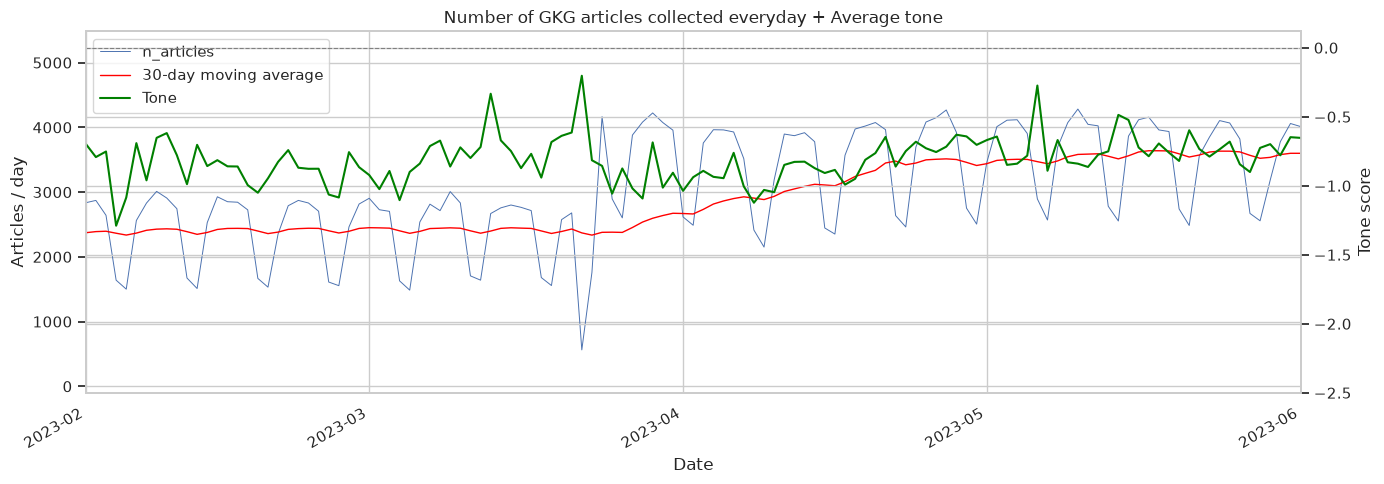

In [ ]:
tone_increase_2023 = con.execute("""The major contributors
    SELECT DATE_TRUNC('day', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS day,
           AVG(Tone) AS avg_tone,
           COUNT(*) AS n
    FROM gkg_final_1pc
    GROUP BY day
    ORDER BY day
""").df()

fig, ax1 = plt.subplots(figsize=(14, 5))

articles_per_day["n_articles"].plot(ax=ax1, linewidth=0.7)
articles_per_day["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax1, linewidth=1, color="red", label="30-day moving average"
)
ax1.set_ylabel("Articles / day")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(tone_increase_2023["day"], tone_increase_2023["avg_tone"], color="green", label="Tone")
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Tone score")

ax1.set_title("Number of GKG articles collected everyday + Average tone")
ax1.set_xlim(pd.to_datetime('2023-02-01'), pd.to_datetime('2023-06-01'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

The tone doesn't seem to be affected.

### 3.2.4 Impact of the main sources
#### 3.2.4.1 All sources

In [59]:
con.execute("""
    CREATE OR REPLACE TABLE all_sources_2023_03_22 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2023-03-22'
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
""")

all_sources_2023_03_22 = con.execute("SELECT * FROM all_sources_2023_03_22").df()

In [60]:
con.execute("""
    CREATE OR REPLACE TABLE all_sources_2023_03_29 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2023-03-29'
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
""")

all_sources_2023_03_29 = con.execute("SELECT * FROM all_sources_2023_03_29").df()

#### 3.2.4.2 Top n sources

In [104]:
n = 20 # top n sources

con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2023_03_22 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
      WHERE g.SourceCommonName_ID IS NOT NULL
      AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2023-03-22'
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC
    LIMIT ?
""",[n] )

top_n_sources_2023_03_22 = con.execute("SELECT * FROM top_n_sources_2023_03_22").df()

In [105]:
con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2023_03_22_after AS
    SELECT
        t.Source_Name,
        COALESCE(a.Articles, 0) AS Articles
    FROM top_n_sources_2023_03_22 t
    LEFT JOIN all_sources_2023_03_29 a
        ON t.Source_Name = a.Source_Name
    ORDER BY Articles DESC;
""")

top_n_sources_2023_03_22_after = con.execute("SELECT * FROM top_n_sources_2023_03_22_after").df()

In [103]:
display(HTML(f"""
<div style="display:flex; gap:30px; align-items:flex-start;">
    <div>
        <h4>2023-03-22</h4>
        {top_n_sources_2023_03_22.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>

    <div>
        <h4>2023-03-22 after</h4>
        {top_n_sources_2023_03_22_after.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>
</div>
""")
)

Source_Name,Source_ID,Articles
businessdayonline.com,7823,130
iheart.com,82787,122
yahoo.com,81,78
zazoom.it,36148,57
finanznachrichten.de,3065,25
news.yam.md,148367,25
indiatimes.com,724,24
uol.com.br,7367,21
cfi.net.cn,61153,21
naslovi.net,31920,19


In [106]:
n = 20 # top n sources

con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2023_03_29 AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
      WHERE g.SourceCommonName_ID IS NOT NULL
      AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE = DATE '2023-03-29'
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC
    LIMIT ?
""",[n] )

top_n_sources_2023_03_29 = con.execute("SELECT * FROM top_n_sources_2023_03_29").df()

In [107]:
con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2023_03_29_before AS
    SELECT
        t.Source_Name,
        COALESCE(a.Articles, 0) AS Articles
    FROM top_n_sources_2023_03_29 t
    LEFT JOIN all_sources_2023_03_22 a
        ON t.Source_Name = a.Source_Name
    ORDER BY Articles DESC;
""")

top_n_sources_2023_03_29_before = con.execute("SELECT * FROM top_n_sources_2023_03_29_before").df()

In [108]:
display(HTML(f"""
<div style="display:flex; gap:30px; align-items:flex-start;">
    <div>
        <h4>2023-03-29 before</h4>
        {top_n_sources_2023_03_29_before.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>

    <div>
        <h4>2023-03-29</h4>
        {top_n_sources_2023_03_29.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>
</div>
""")
)

Source_Name,Articles
iheart.com,158
yahoo.com,144
indiatimes.com,72
biztoc.com,54
goskagit.com,53
finanznachrichten.de,17
uol.com.br,14
msn.com,13
modernreaders.com,9
zazoom.it,8


#### 3.2.4.3 Percentage variation between the extrema - number of articles collected

In [65]:
nb_sources_all_sources = [
    all_sources_2023_03_22["Articles"].sum(),
    all_sources_2023_03_29["Articles"].sum()    
]

nb_sources_top_n_sources_2023_03_22 = [
    top_n_sources_2023_03_22["Articles"].sum(),
    top_n_sources_2023_03_22_after["Articles"].sum()
]

nb_sources_top_n_sources_2023_03_29 = [
    top_n_sources_2023_03_29_before["Articles"].sum(),
    top_n_sources_2023_03_29["Articles"].sum()    
]

nb_sources_minus_top_n_sources_2023_03_22 = [
    nb_sources_all_sources[0] - nb_sources_top_n_sources_2023_03_22[0],
    nb_sources_all_sources[1] - nb_sources_top_n_sources_2023_03_22[1]
]

nb_sources_minus_top_n_sources_2023_03_29 = [
    nb_sources_all_sources[0] - nb_sources_top_n_sources_2023_03_29[0],
    nb_sources_all_sources[1] - nb_sources_top_n_sources_2023_03_29[1]
]

In [66]:
res_values_all_sources = round(100 * (nb_sources_all_sources[1] / nb_sources_all_sources[0] - 1), 2)

res_values_top_n_sources_2023_03_22 = round(100 * (nb_sources_top_n_sources_2023_03_22[1] / nb_sources_top_n_sources_2023_03_22[0] - 1), 2)

res_values_minus_top_n_sources_2023_03_22 = round(100 * (nb_sources_minus_top_n_sources_2023_03_22[1] / nb_sources_minus_top_n_sources_2023_03_22[0] - 1), 2)

res_values_top_n_sources_2023_03_29 = round(100 * (nb_sources_top_n_sources_2023_03_29[1] / nb_sources_top_n_sources_2023_03_29[0] - 1), 2)

res_values_minus_top_n_sources_2023_03_29 = round(100 * (nb_sources_minus_top_n_sources_2023_03_29[1] / nb_sources_minus_top_n_sources_2023_03_29[0] - 1), 2)

In [67]:
print ("percentage variation all sources :", res_values_all_sources, "%\n")

print ("percentage variation top n sources 2023-03-22 :", res_values_top_n_sources_2023_03_22, "%\n")

print ("percentage variation minus top n sources 2023-03-22 :", res_values_minus_top_n_sources_2023_03_22, "%\n")

print ("percentage variation top n sources 2023-03-29 :", res_values_top_n_sources_2023_03_29, "%\n")

print ("percentage variation minus top n sources 2023-03-29 :", res_values_minus_top_n_sources_2023_03_29, "%\n")

percentage variation all sources : 638.59 %

percentage variation top n sources 2023-03-22 : 200.97 %

percentage variation minus top n sources 2023-03-22 : 674.99 %

percentage variation top n sources 2023-03-29 : 7142.58 %

percentage variation minus top n sources 2023-03-29 : 571.95 %



##### 3.2.4.3.1 Top sources - 8 days
Given the surprising results (especially on the 29th), we wanted to verify whether major contributors were responsible for the temporal anomaly by analyzing the presence of sources over an eight-day period. 

In [110]:
con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2023_03_22_week AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-15'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-03-22'
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC
    LIMIT ?
""",[n] )

top_n_sources_2023_03_22_week = con.execute("SELECT * FROM top_n_sources_2023_03_22_week").df()

In [111]:
con.execute("""
    CREATE OR REPLACE TABLE top_n_sources_2023_03_29_week AS
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_final g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
        WHERE g.SourceCommonName_ID IS NOT NULL
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE >= DATE '2023-03-29'
        AND STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE <= DATE '2023-04-05'
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC
    LIMIT ?
""",[n] )

top_n_sources_2023_03_29_week = con.execute("SELECT * FROM top_n_sources_2023_03_29_week").df()

In [112]:
display(HTML(f"""
<div style="display:flex; gap:30px; align-items:flex-start;">
    <div>
        <h4>2023-03-22 week</h4>
        {top_n_sources_2023_03_22_week.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>

    <div>
        <h4>2023-03-29 week</h4>
        {top_n_sources_2023_03_29_week.style.format({"Articles": "{:,}"}).hide(axis="index").to_html()}
    </div>
</div>
""")
)

Source_Name,Source_ID,Articles
businessdayonline.com,7823,"41,581"
iheart.com,82787,"32,191"
yahoo.com,81,"24,192"
zazoom.it,36148,"23,436"
indiatimes.com,724,"8,592"
news.yam.md,148367,"7,018"
finanznachrichten.de,3065,"6,955"
sohu.com,57878,"6,945"
cfi.net.cn,61153,"6,227"
uol.com.br,7367,"5,582"


The largest contributors are present both before and after the peak, with the exception of msn, tribunnews and biztoc. This reassures us that they are not the cause of the temporal anomaly.

#### 3.2.4.4 Percentage of articles published by the top sources at each extrema
##### 3.2.4.4.1 Top n sources 2023-03-22 
We want to see what percentage the top sources of 2023-03-22 (pre-increase top sources) accounts for on each extrema.

In [86]:
top_n_sources_2023_03_29_max = con.execute("""
    SELECT i.Source_Name, t.Articles
    FROM (
        SELECT Source_Name
        FROM top_n_sources_2023_03_22
        INTERSECT
        SELECT Source_Name
        FROM top_n_sources_2023_03_29
    ) AS i
    JOIN top_n_sources_2023_03_29 AS t
        ON i.Source_Name = t.Source_Name
    ORDER BY t.Articles DESC
""").df()

display(top_n_sources_2023_03_29_max.style.format({"Articles": "{:,}"}).hide(axis="index"))

Source_Name,Articles
iheart.com,"5,297"
yahoo.com,"4,863"


In [88]:
res_pc_articles_by_top_n_sources_2023_03_22 = round(100 * (top_n_sources_2023_03_22["Articles"].sum() / nb_sources_all_sources[0]), 2)
res_pc_articles_by_top_n_sources_2023_03_29 = round(100 * (top_n_sources_2023_03_29_max["Articles"].sum() / nb_sources_all_sources[1]), 2)

print ("percentage articles published by the top n sources 2023-03-22 :", res_pc_articles_by_top_n_sources_2023_03_22, "%\n")
print ("percentage articles published by the top n sources 2023-03-22 :", res_pc_articles_by_top_n_sources_2023_03_29, "%\n")

percentage articles published by the top n sources 2023-03-22 : 1.24 %

percentage articles published by the top n sources 2023-03-22 : 2.5 %



##### 3.2.4.4.2 Top n sources 2023-03-29 
We want to see what percentage the top sources of 2023-03-29 (post-increase top sources) accounts for on each extrema.

In [89]:
top_n_sources_2023_03_22_min = con.execute("""
    SELECT i.Source_Name, t.Articles
    FROM (
        SELECT Source_Name
        FROM top_n_sources_2023_03_22
        INTERSECT
        SELECT Source_Name
        FROM top_n_sources_2023_03_29
    ) AS i
    JOIN top_n_sources_2023_03_22 AS t
        ON i.Source_Name = t.Source_Name
    ORDER BY t.Articles DESC
""").df()

display(top_n_sources_2023_03_22_min.style.format({"Articles": "{:,}"}).hide(axis="index"))

Source_Name,Articles
iheart.com,158
yahoo.com,144


In [90]:
res_pc_articles_by_top_n_sources_2023_03_22 = round(100 * (top_n_sources_2023_03_22_min["Articles"].sum() / nb_sources_all_sources[0]), 2)
res_pc_articles_by_top_n_sources_2023_03_29 = round(100 * (top_n_sources_2023_03_29["Articles"].sum() / nb_sources_all_sources[1]), 2)

print ("percentage articles published by the top n sources 2023-03-22 :", res_pc_articles_by_top_n_sources_2023_03_22, "%\n")
print ("percentage articles published by the top n sources 2023-03-22 :", res_pc_articles_by_top_n_sources_2023_03_29, "%\n")

percentage articles published by the top n sources 2023-03-22 : 0.55 %

percentage articles published by the top n sources 2023-03-22 : 0.31 %



Since the proportion of articles published by top contributors are low at both points on the curve, their impact remains consistent even when there is a sharp fluctuation in the volume of published articles. Therefore, the top contributors don't bias the results!